In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install seaborn


In [ ]:
pip install dmba


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 66.6 MB/s eta 0:00:00


In [ ]:
# Exploratory Data Analysis (EDA) Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Cleaning and Analysis Modules
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

# Model Building Modules
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter Tuning Modules
from sklearn.model_selection import GridSearchCV

# Model Evaluation Modules
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, accuracy_score, f1_score, r2_score
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import recall_score

# Warning Suppression Modules
import warnings
warnings.filterwarnings('ignore')

# Matplotlib and Formatting Options
%matplotlib inline
pd.options.display.max_columns = 100
pd.options.display.max_rows = 900
pd.set_option('float_format', '{:f}'.format)

# Check available styles in Matplotlib and choose one
import matplotlib.pyplot as plt
if 'seaborn-darkgrid' in plt.style.available:
    plt.style.use('seaborn-darkgrid')
else:
    # Use a different style if 'seaborn-darkgrid' is not available
    plt.style.use('ggplot')  # Or another style like 'fivethirtyeight', 'seaborn', etc.

# Additional Libraries and Modules
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from dmba import classificationSummary, gainsChart, liftChart
from dmba.metric import AIC_score
from scipy import stats
import math
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
import matplotlib.pylab as plt

# Uncomment the following line if you're looking for ordinal multi-class (more than 2 levels)
# from mord import LogisticIT



Colab environment detected.


In [ ]:
#loading the dataset

fraud_df = pd.read_csv('/content/drive/MyDrive/fraudTrain.csv')

fraud_df.head()

,Index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,1/1/2019 0:00,2703190000000000.000000,"fraud_Rippin, Kub and Mann",misc_net,4.970000,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.078800,-81.178100,3495,"Psychologist, counselling",3/9/1988,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,1/1/2019 0:00,630423000000.000000,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230000,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.887800,-118.210500,149,Special educational needs teacher,6/21/1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,1/1/2019 0:00,38859500000000.000000,fraud_Lind-Buckridge,entertainment,220.110000,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.180800,-112.262000,4154,Nature conservation officer,1/19/1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,1/1/2019 0:01,3534090000000000.000000,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.230600,-112.113800,1939,Patent attorney,1/12/1967,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,1/1/2019 0:03,375534000000000.000000,fraud_Keeling-Crist,misc_pos,41.960000,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.420700,-79.462900,99,Dance movement psychotherapist,3/28/1986,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
fraud_df.drop(fraud_df.columns[:1], axis=1, inplace=True)
fraud_df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,1/1/2019 0:00,2703190000000000.000000,"fraud_Rippin, Kub and Mann",misc_net,4.970000,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.078800,-81.178100,3495,"Psychologist, counselling",3/9/1988,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1/1/2019 0:00,630423000000.000000,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230000,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.887800,-118.210500,149,Special educational needs teacher,6/21/1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,1/1/2019 0:00,38859500000000.000000,fraud_Lind-Buckridge,entertainment,220.110000,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.180800,-112.262000,4154,Nature conservation officer,1/19/1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,1/1/2019 0:01,3534090000000000.000000,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.230600,-112.113800,1939,Patent attorney,1/12/1967,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,1/1/2019 0:03,375534000000000.000000,fraud_Keeling-Crist,misc_pos,41.960000,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.420700,-79.462900,99,Dance movement psychotherapist,3/28/1986,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
#converting trans_date_trans_time into datetime
fraud_df['trans_date_trans_time'] = pd.to_datetime(fraud_df['trans_date_trans_time'])
print(fraud_df.dtypes['trans_date_trans_time'])
fraud_df.head()

datetime64[ns]


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:00,2703190000000000.000000,"fraud_Rippin, Kub and Mann",misc_net,4.970000,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.078800,-81.178100,3495,"Psychologist, counselling",3/9/1988,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:00,630423000000.000000,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230000,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.887800,-118.210500,149,Special educational needs teacher,6/21/1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:00,38859500000000.000000,fraud_Lind-Buckridge,entertainment,220.110000,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.180800,-112.262000,4154,Nature conservation officer,1/19/1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:00,3534090000000000.000000,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.230600,-112.113800,1939,Patent attorney,1/12/1967,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:00,375534000000000.000000,fraud_Keeling-Crist,misc_pos,41.960000,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.420700,-79.462900,99,Dance movement psychotherapist,3/28/1986,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
#dtypes of the columns
fraud_df.dtypes

,0
trans_date_trans_time,datetime64[ns]
cc_num,float64
merchant,object
category,object
amt,float64
first,object
last,object
gender,object
street,object
city,object


In [ ]:
#let us look at the number of unique values in the dataset
fraud_df.nunique()

,0
trans_date_trans_time,476595
cc_num,943
merchant,693
category,14
amt,48602
first,348
last,479
gender,2
street,965
city,879


In [ ]:
# deriving additonal columns from 'trans_date_trans_time'
#deriving hour
fraud_df['trans_hour'] = fraud_df['trans_date_trans_time'].dt.hour
#deriving 'day of the week'
fraud_df['trans_day_of_week'] = fraud_df['trans_date_trans_time'].dt.dayofweek + 1
fraud_df['trans_day_of_week'] = fraud_df['trans_day_of_week'].astype(int)
#deriving 'year_month'
fraud_df['trans_year_month'] = fraud_df['trans_date_trans_time'].dt.to_period('M')

fraud_df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_day_of_week,trans_year_month
0,2019-01-01 00:00:00,2703190000000000.000000,"fraud_Rippin, Kub and Mann",misc_net,4.970000,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.078800,-81.178100,3495,"Psychologist, counselling",3/9/1988,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,2,2019-01
1,2019-01-01 00:00:00,630423000000.000000,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230000,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.887800,-118.210500,149,Special educational needs teacher,6/21/1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,2,2019-01
2,2019-01-01 00:00:00,38859500000000.000000,fraud_Lind-Buckridge,entertainment,220.110000,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.180800,-112.262000,4154,Nature conservation officer,1/19/1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,2,2019-01
3,2019-01-01 00:01:00,3534090000000000.000000,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.230600,-112.113800,1939,Patent attorney,1/12/1967,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,2,2019-01
4,2019-01-01 00:03:00,375534000000000.000000,fraud_Keeling-Crist,misc_pos,41.960000,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.420700,-79.462900,99,Dance movement psychotherapist,3/28/1986,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,2,2019-01


In [ ]:
fraud_df['dob'] = pd.to_datetime(fraud_df['dob'])
fraud_df['age'] = ((fraud_df['trans_date_trans_time'] - fraud_df['dob']).dt.days / 365.25).astype(int)

fraud_df['age'].head()


,age
0,30
1,40
2,56
3,51
4,32


In [ ]:
#dropping variables which are not usefull for the Visualization and analytics
fraud_df.drop(['trans_date_trans_time','first', 'last', 'dob'] , axis=1, inplace=True)
fraud_df.head()

,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_day_of_week,trans_year_month,age
0,2703190000000000.000000,"fraud_Rippin, Kub and Mann",misc_net,4.970000,F,561 Perry Cove,Moravian Falls,NC,28654,36.078800,-81.178100,3495,"Psychologist, counselling",0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,2,2019-01,30
1,630423000000.000000,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230000,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.887800,-118.210500,149,Special educational needs teacher,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,2,2019-01,40
2,38859500000000.000000,fraud_Lind-Buckridge,entertainment,220.110000,M,594 White Dale Suite 530,Malad City,ID,83252,42.180800,-112.262000,4154,Nature conservation officer,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,2,2019-01,56
3,3534090000000000.000000,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000000,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.230600,-112.113800,1939,Patent attorney,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,2,2019-01,51
4,375534000000000.000000,fraud_Keeling-Crist,misc_pos,41.960000,M,408 Bradley Rest,Doe Hill,VA,24433,38.420700,-79.462900,99,Dance movement psychotherapist,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,2,2019-01,32


In [ ]:
#checking the dataset info
fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column             Non-Null Count    Dtype    
---  ------             --------------    -----    
 0   cc_num             1048575 non-null  float64  
 1   merchant           1048575 non-null  object   
 2   category           1048575 non-null  object   
 3   amt                1048575 non-null  float64  
 4   gender             1048575 non-null  object   
 5   street             1048575 non-null  object   
 6   city               1048575 non-null  object   
 7   state              1048575 non-null  object   
 8   zip                1048575 non-null  int64    
 9   lat                1048575 non-null  float64  
 10  long               1048575 non-null  float64  
 11  city_pop           1048575 non-null  int64    
 12  job                1048575 non-null  object   
 13  trans_num          1048575 non-null  object   
 14  unix_time          1048575 non-null  int64    
 15

In [ ]:
#converting data types that should be categorical into "category"

fraud_df['category'] = fraud_df['category'].astype('category')
fraud_df['gender'] = fraud_df['gender'].astype('category')
fraud_df['is_fraud'] = fraud_df['is_fraud'].astype('category')

fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column             Non-Null Count    Dtype    
---  ------             --------------    -----    
 0   cc_num             1048575 non-null  float64  
 1   merchant           1048575 non-null  object   
 2   category           1048575 non-null  category 
 3   amt                1048575 non-null  float64  
 4   gender             1048575 non-null  category 
 5   street             1048575 non-null  object   
 6   city               1048575 non-null  object   
 7   state              1048575 non-null  object   
 8   zip                1048575 non-null  int64    
 9   lat                1048575 non-null  float64  
 10  long               1048575 non-null  float64  
 11  city_pop           1048575 non-null  int64    
 12  job                1048575 non-null  object   
 13  trans_num          1048575 non-null  object   
 14  unix_time          1048575 non-null  int64    
 15

In [ ]:
#determing the shape of the dataset
fraud_df.shape

(1048575, 22)

In [ ]:
#describing the dataset
fraud_df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,trans_hour,trans_day_of_week,age
count,1048575.000000,1048575.000000,1048575.000000,1048575.000000,1048575.000000,1048575.000000,1048575.000000,1048575.000000,1048575.000000,1048575.000000,1048575.000000,1048575.000000
mean,417156502027958336.000000,70.279095,48801.590604,38.533364,-90.226256,89057.759063,1344905832.778656,38.533463,-90.226477,12.800773,4.135594,45.386577
std,1308811172818672640.000000,159.951841,26898.040351,5.076852,13.758582,302435.057620,10196997.483775,5.111233,13.770929,6.816861,2.200499,17.380873
min,60416207185.000000,1.000000,1257.000000,20.027100,-165.672300,23.000000,1325376018.000000,19.027785,-166.671242,0.000000,1.000000,13.000000
25%,180040000000000.000000,9.640000,26237.000000,34.620500,-96.798000,743.000000,1336682353.000000,34.729540,-96.898639,7.000000,2.000000,32.000000
50%,3520550000000000.000000,47.450000,48174.000000,39.354300,-87.476900,2456.000000,1344901521.000000,39.362945,-87.439226,14.000000,4.000000,43.000000
75%,4642260000000000.000000,83.050000,72042.000000,41.940400,-80.158000,20328.000000,1354366012.000000,41.956021,-80.232279,19.000000,6.000000,56.000000
max,4992350000000000000.000000,28948.900000,99783.000000,66.693300,-67.950300,2906700.000000,1362931730.000000,67.510267,-66.950902,23.000000,7.000000,95.000000


In [ ]:
#let us check the percentage of fraudulent data points in our dataset
100 * fraud_df.groupby('is_fraud').size() / len(fraud_df)

,0
is_fraud,
0,99.427223
1,0.572777


In [ ]:
#looking at distribution of amount
pd.concat(
    [fraud_df['amt'].describe(percentiles = [0.5,0.95,0.999]).reset_index().rename(columns={'index': 'Row Type', 'amt':'Total Amount Distribution'}),
     fraud_df.loc[fraud_df['is_fraud']==0,['amt']].describe(percentiles = [0.5,0.95,0.999]).reset_index(drop = 1).rename(columns={'amt':'Non-Fraud Amount Distribution'}),
     fraud_df.loc[fraud_df['is_fraud']==1,['amt']].describe(percentiles = [0.5,0.95,0.999]).reset_index(drop = 1).rename(columns={'amt':'Fraud Amount Distribution'})], axis=1)

,Row Type,Total Amount Distribution,Non-Fraud Amount Distribution,Fraud Amount Distribution
0,count,1048575.000000,1042569.000000,6006.000000
1,mean,70.279095,67.627445,530.573492
2,std,159.951841,153.695606,391.333069
3,min,1.000000,1.000000,1.180000
4,50%,47.450000,47.220000,391.165000
5,95%,196.260000,189.940000,1085.052500
6,99.9%,1496.830880,1502.239520,1289.066100
7,max,28948.900000,28948.900000,1371.810000


In [ ]:
#year_month vs number of transactions
df_timeline01 = fraud_df.groupby(fraud_df['trans_year_month'])[['trans_num','cc_num']].nunique().reset_index()
df_timeline01.columns = ['year_month','num_of_transactions','customers']
df_timeline01

,year_month,num_of_transactions,customers
0,2019-01,52525,893
1,2019-02,49866,898
2,2019-03,70939,896
3,2019-04,68078,893
4,2019-05,72532,890
5,2019-06,86064,888
6,2019-07,86596,890
7,2019-08,87359,891
8,2019-09,70652,893
9,2019-10,68758,891


In [ ]:
#constructing the category-transaction count distribution
df_category = fraud_df[['category','trans_num']].groupby(['category']).count().reset_index()
df_category.columns = ['category', 'category_count']

#creating the zip-fraud distribution
df_fraud_category = fraud_df[['category', 'trans_num', 'is_fraud']].groupby(['category','is_fraud']).count().reset_index()
df_fraud_category.columns = ['category', 'is_fraud', 'Transaction count']

df_fraud_category = df_fraud_category.merge(df_category[['category', 'category_count']], how='inner', on='category')

df_fraud_category['Transaction percentage'] = (df_fraud_category['Transaction count']/df_fraud_category['category_count'])*100

#viewing the top categories with high fraudulent transaction volumes
df_fraud_category[df_fraud_category['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False)


,category,is_fraud,Transaction count,category_count,Transaction percentage
23,shopping_net,1,1375,78899,1.742734
17,misc_net,1,742,51082,1.452566
9,grocery_pos,1,1396,99906,1.397313
25,shopping_pos,1,662,94353,0.701621
5,gas_transport,1,498,106430,0.467913
27,travel,1,100,32830,0.304599
19,misc_pos,1,194,64492,0.300813
7,grocery_net,1,110,36719,0.299572
1,entertainment,1,185,75981,0.243482
21,personal_care,1,172,73498,0.234020


In [ ]:
#categories with more than one percent fraudulent transactions
df_fraud_category.loc[(df_fraud_category.is_fraud == 1) & (df_fraud_category['Transaction percentage'] >= 0.1)]

,category,is_fraud,Transaction count,category_count,Transaction percentage
1,entertainment,1,185,75981,0.243482
3,food_dining,1,121,74041,0.163423
5,gas_transport,1,498,106430,0.467913
7,grocery_net,1,110,36719,0.299572
9,grocery_pos,1,1396,99906,1.397313
11,health_fitness,1,104,69362,0.149938
13,home,1,153,99578,0.153648
15,kids_pets,1,194,91404,0.212245
17,misc_net,1,742,51082,1.452566
19,misc_pos,1,194,64492,0.300813


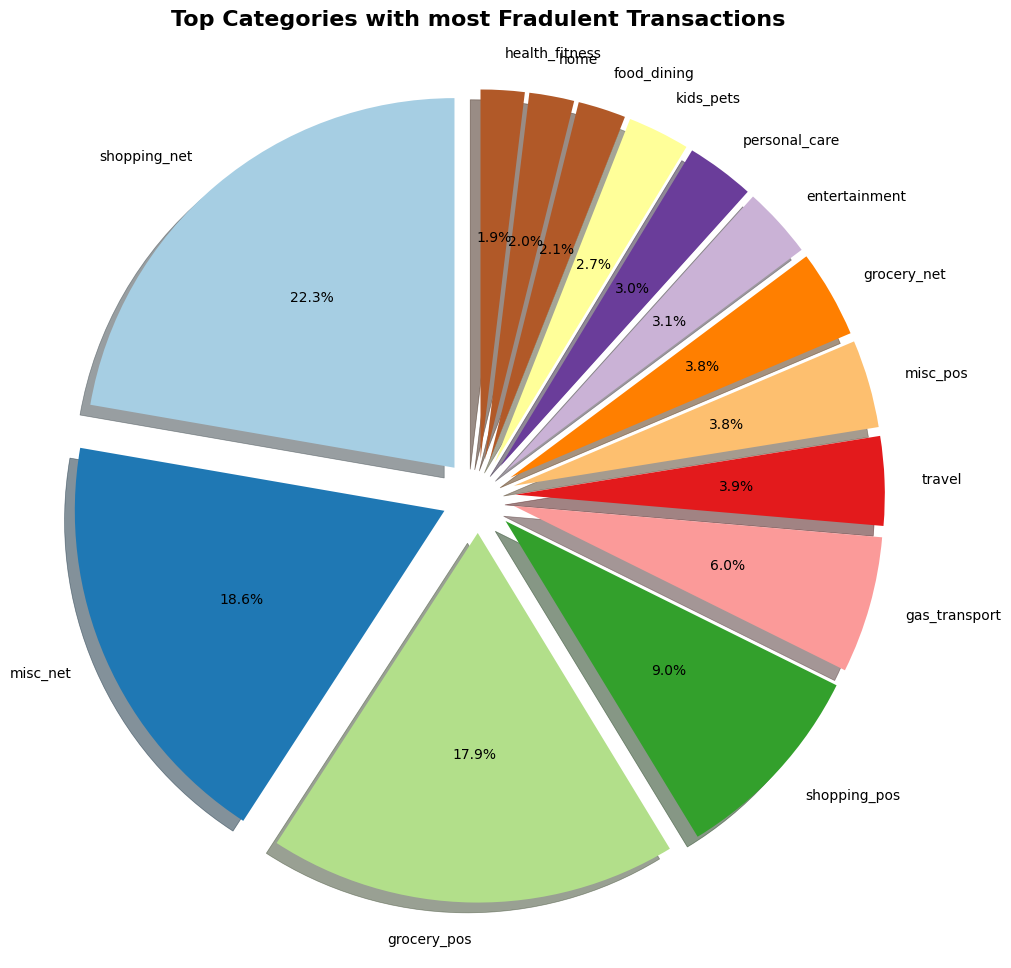

In [ ]:
import matplotlib.pyplot as plt

# Assuming df_fraud_category is your DataFrame with columns 'category', 'is_fraud', and 'Transaction percentage'
# Filter the DataFrame for categories with more than 1% fraudulent transactions and get the top 25
subset_df = df_fraud_category[(df_fraud_category['is_fraud'] == 1) & (df_fraud_category['Transaction percentage'] >= 0.1)].nlargest(25, 'Transaction percentage')

# Define a color palette
colors = plt.cm.Paired(range(len(subset_df)))

# Create a pie chart
plt.figure(figsize=(12, 12))
plt.pie(subset_df['Transaction percentage'], labels=subset_df['category'], autopct='%1.1f%%', startangle=90,
        colors=colors, shadow=True, explode=[0.1] * len(subset_df))
plt.title('Top Categories with most Fradulent Transactions', fontsize=16, fontweight='bold')

plt.show()

In [ ]:
# Columns of the dataframe
fraud_df.columns

Index(['cc_num', 'merchant', 'category', 'amt', 'gender', 'street', 'city',
       'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'trans_num',
       'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'trans_hour',
       'trans_day_of_week', 'trans_year_month', 'age'],
      dtype='object')

In [ ]:
# Create custom bins and labels for age categories
custom_bins = [13, 19, 32, 42, 50,62 , float('inf')]
custom_labels = ['Teenagers', 'Young Adults', 'Adults', 'Middle-aged', 'Seniors', 'Retired']

# Apply the binning to create a new 'age_category' column
fraud_df['age_category'] = pd.cut(fraud_df['age'], bins=custom_bins, labels=custom_labels, right=False)

# Display the result
print(fraud_df[['age', 'age_category']].tail())

         age  age_category
1048570   76       Retired
1048571   20  Young Adults
1048572   67       Retired
1048573   29  Young Adults
1048574   22  Young Adults


In [ ]:
x =  [ 'amt', 'gender','lat', 'long', 'city_pop',  'trans_hour','trans_day_of_week', 'age','is_fraud','age_category']
fraud_df = pd.get_dummies(fraud_df[x], drop_first=True)
fraud_df.columns

Index(['amt', 'lat', 'long', 'city_pop', 'trans_hour', 'trans_day_of_week',
       'age', 'gender_M', 'is_fraud_1', 'age_category_Young Adults',
       'age_category_Adults', 'age_category_Middle-aged',
       'age_category_Seniors', 'age_category_Retired'],
      dtype='object')

In [ ]:
from imblearn.over_sampling import SMOTE


predictors =  [ 'amt',  'city_pop', 'trans_hour', 'age', 'gender_M','lat', 'long','trans_day_of_week','age_category_Young Adults',
       'age_category_Adults', 'age_category_Middle-aged',
       'age_category_Seniors', 'age_category_Retired']
# partition data
X = fraud_df[predictors]
y = fraud_df['is_fraud_1']

# First perform the train-test split
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)

# Then apply SMOTE only to the training data
smote = SMOTE(random_state=42)
train_X_resampled, train_y_resampled = smote.fit_resample(train_X, train_y)

# Check the distribution in both training and validation sets
print('Original training set distribution:')
print(train_y.value_counts())
print('\nResampled training set distribution:')
print(train_y_resampled.value_counts())
print('\nValidation set distribution:')
print(valid_y.value_counts())

Original training set distribution:
is_fraud_1
False    625463
True       3682
Name: count, dtype: int64

Resampled training set distribution:
is_fraud_1
False    625463
True     625463
Name: count, dtype: int64

Validation set distribution:
is_fraud_1
False    417106
True       2324
Name: count, dtype: int64


XG boost

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Assuming X is your feature matrix and y is the target variable
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.4, random_state=42)

# Create an XGBoost classifier
xgb_classifier = XGBClassifier(random_state=42)

# Train the model
xgb_classifier.fit(train_X, train_y)

# Make predictions on the testing set, not the training set
pred_y_xg_a = xgb_classifier.predict(test_X)

# Evaluate the model
accuracy = accuracy_score(test_y, pred_y_xg_a)
print(f"Accuracy: {accuracy}")
print("\nXGBoost Classifier:")
print(classification_report(test_y, pred_y_xg_a))

Accuracy: 0.9972534153494027

XGBoost Classifier:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00    417045
        True       0.86      0.61      0.72      2385

    accuracy                           1.00    419430
   macro avg       0.93      0.81      0.86    419430
weighted avg       1.00      1.00      1.00    419430



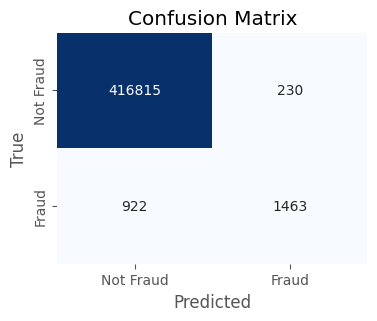

In [ ]:
# Generate confusion matrix
conf_matrix_xg_a = confusion_matrix(test_y, pred_y_xg_a)

# Visualize the confusion matrix using seaborn
plt.figure(figsize=(4,3))
sns.heatmap(conf_matrix_xg_a, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, classification_report

# Assuming X is your feature matrix and y is the target variable
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.4, random_state=42)

# Apply undersampling to the training set
undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
train_X_resampled, train_y_resampled = undersampler.fit_resample(train_X, train_y)

# Create an XGBoost classifier
xgb_classifier = XGBClassifier(random_state=42)

# Train the model on the resampled data
xgb_classifier.fit(train_X_resampled, train_y_resampled)

# Make predictions on the testing set
pred_y_xg_b = xgb_classifier.predict(test_X)

# Evaluate the model
accuracy = accuracy_score(test_y, pred_y_xg_b)
print(f"Accuracy: {accuracy}")
print("\nXGBoost Classifier:")
print(classification_report(test_y, pred_y_xg_b))

Accuracy: 0.9460052928975038

XGBoost Classifier:
              precision    recall  f1-score   support

       False       1.00      0.95      0.97    417045
        True       0.09      0.94      0.17      2385

    accuracy                           0.95    419430
   macro avg       0.55      0.94      0.57    419430
weighted avg       0.99      0.95      0.97    419430



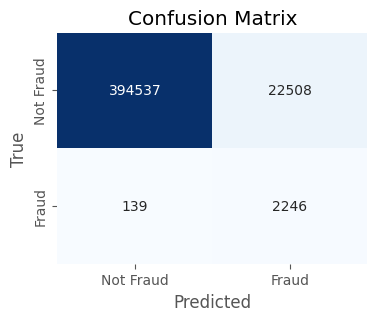

In [ ]:
# Generate confusion matrix
conf_matrix_xg_b = confusion_matrix(test_y, pred_y_xg_b)

# Visualize the confusion matrix using seaborn
plt.figure(figsize=(4,3))
sns.heatmap(conf_matrix_xg_b, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, classification_report

# Assuming X is your feature matrix and y is the target variable
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.4, random_state=42)

# Apply undersampling to the training set
undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
train_X_resampled, train_y_resampled = undersampler.fit_resample(train_X, train_y)

# Create an XGBoost classifier
xgb_classifier = XGBClassifier(random_state=42)

# Train the model on the resampled data
xgb_classifier.fit(train_X_resampled, train_y_resampled)

# Get feature importance scores
feature_importance = xgb_classifier.feature_importances_

# Create a DataFrame to display feature importance scores
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print feature importance
print("Feature Importance:")
print(feature_importance_df)

# Make predictions on the testing set
pred_y_xg_b = xgb_classifier.predict(test_X)

# Evaluate the model
accuracy = accuracy_score(test_y, pred_y_xg_b)
print(f"\nAccuracy: {accuracy}")
print("\nXGBoost Classifier:")
print(classification_report(test_y, pred_y_xg_b))

Feature Importance:
                      Feature  Importance
0                         amt    0.459835
2                  trans_hour    0.182094
10   age_category_Middle-aged    0.047633
3                         age    0.046501
4                    gender_M    0.044862
1                    city_pop    0.036529
11       age_category_Seniors    0.036085
8   age_category_Young Adults    0.031754
9         age_category_Adults    0.030183
5                         lat    0.029014
6                        long    0.028204
7           trans_day_of_week    0.027307
12       age_category_Retired    0.000000

Accuracy: 0.9460052928975038

XGBoost Classifier:
              precision    recall  f1-score   support

       False       1.00      0.95      0.97    417045
        True       0.09      0.94      0.17      2385

    accuracy                           0.95    419430
   macro avg       0.55      0.94      0.57    419430
weighted avg       0.99      0.95      0.97    419430



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create a Logistic Regression classifier
logreg_classifier = LogisticRegression(random_state=42)

# Train the model on the original data
logreg_classifier.fit(train_X, train_y)

# Make predictions on the testing set
pred_y_logreg_a = logreg_classifier.predict(test_X)

# Evaluate the model
accuracy_logreg = accuracy_score(test_y, pred_y_logreg_a)
print(f"Logistic Regression Accuracy: {accuracy_logreg}")
print("\nLogistic Regression Classifier:")
print(classification_report(test_y, pred_y_logreg_a))


Logistic Regression Accuracy: 0.9937462747061488

Logistic Regression Classifier:
              precision    recall  f1-score   support

       False       0.99      1.00      1.00    417045
        True       0.00      0.00      0.00      2385

    accuracy                           0.99    419430
   macro avg       0.50      0.50      0.50    419430
weighted avg       0.99      0.99      0.99    419430



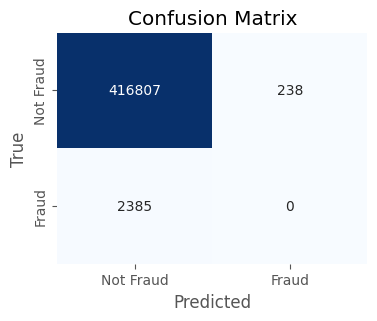

In [ ]:
# Generate confusion matrix
conf_matrix_logreg_a = confusion_matrix(test_y, pred_y_logreg_a)

# Visualize the confusion matrix using seaborn
plt.figure(figsize=(4,3))
sns.heatmap(conf_matrix_logreg_a, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

# Apply undersampling to the training set
undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
train_X_resampled, train_y_resampled = undersampler.fit_resample(train_X, train_y)

# Create a Logistic Regression classifier
logreg_classifier = LogisticRegression(random_state=42)

# Train the model on the resampled data
logreg_classifier.fit(train_X_resampled, train_y_resampled)

# Make predictions on the testing set
pred_y_logreg_b = logreg_classifier.predict(test_X)

# Evaluate the model
accuracy_logreg = accuracy_score(test_y, pred_y_logreg_b)
print(f"Logistic Regression Accuracy: {accuracy_logreg}")
print("\nLogistic Regression Classifier:")
print(classification_report(test_y, pred_y_logreg_b))

Logistic Regression Accuracy: 0.954376177192857

Logistic Regression Classifier:
              precision    recall  f1-score   support

       False       1.00      0.96      0.98    417045
        True       0.09      0.74      0.16      2385

    accuracy                           0.95    419430
   macro avg       0.54      0.85      0.57    419430
weighted avg       0.99      0.95      0.97    419430



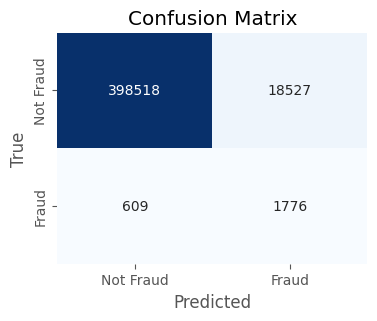

In [ ]:
# Generate confusion matrix
conf_matrix_logreg_b = confusion_matrix(test_y, pred_y_logreg_b)

# Visualize the confusion matrix using seaborn
plt.figure(figsize=(4,3))
sns.heatmap(conf_matrix_logreg_b, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

# Apply undersampling to the training set
undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
train_X_resampled, train_y_resampled = undersampler.fit_resample(train_X, train_y)

# Create a Logistic Regression classifier
logreg_classifier = LogisticRegression(random_state=42)

# Train the model on the resampled data
logreg_classifier.fit(train_X_resampled, train_y_resampled)

# Get coefficients and intercept
coefficients = logreg_classifier.coef_
intercept = logreg_classifier.intercept_

# Create a DataFrame to display coefficients
coefficients_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients.flatten()})
coefficients_df = coefficients_df.sort_values(by='Coefficient', ascending=False)

# Print coefficients and intercept
print("Coefficients:")
print(coefficients_df)
print("\nIntercept:")
print(intercept)

# Make predictions on the testing set
pred_y_logreg_b = logreg_classifier.predict(test_X)


# Evaluate the model
accuracy_logreg = accuracy_score(test_y, pred_y_logreg_b)
print(f"\nAccuracy: {accuracy_logreg}")
print("\nLogistic Regression Classifier:")
print(classification_report(test_y, pred_y_logreg_b))
## fit a logistic regression (set penalty=l2 (a penalty of L2 will force some coefficients to be small,
#essentially focusing on a fewer variables) and C=1e42 avoids regularization, C denotes how strong we want
#regularization to be. A smaller C will make regularization stronger )
logit_reg = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
logit_reg.fit(train_X, train_y)

Coefficients:
                      Feature  Coefficient
0                         amt     0.006739
6                        long     0.006011
3                         age     0.002153
11       age_category_Seniors     0.000411
10   age_category_Middle-aged     0.000308
12       age_category_Retired     0.000060
1                    city_pop    -0.000000
4                    gender_M    -0.000342
8   age_category_Young Adults    -0.000410
7           trans_day_of_week    -0.000588
9         age_category_Adults    -0.000999
5                         lat    -0.016289
2                  trans_hour    -0.025499

Intercept:
[-0.00050839]

Accuracy: 0.954376177192857

Logistic Regression Classifier:
              precision    recall  f1-score   support

       False       1.00      0.96      0.98    417045
        True       0.09      0.74      0.16      2385

    accuracy                           0.95    419430
   macro avg       0.54      0.85      0.57    419430
weighted avg       0.99 

LogisticRegression(C=1e+42, solver='liblinear')

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create a Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model on the original data
dt_classifier.fit(train_X, train_y)

# Make predictions on the testing set
pred_y_dt_a = dt_classifier.predict(test_X)

# Evaluate the model
accuracy_dt = accuracy_score(test_y, pred_y_dt_a)
print(f"Decision Tree Accuracy: {accuracy_dt}")
print("\nDecision Tree Classifier:")
print(classification_report(test_y, pred_y_dt_a))

Decision Tree Accuracy: 0.9953031495124336

Decision Tree Classifier:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00    417045
        True       0.58      0.62      0.60      2385

    accuracy                           1.00    419430
   macro avg       0.79      0.81      0.80    419430
weighted avg       1.00      1.00      1.00    419430



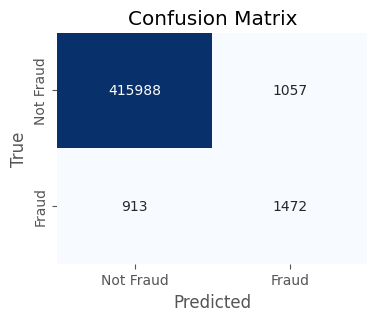

In [ ]:
# Generate confusion matrix
conf_matrix_tree_a = confusion_matrix(test_y, pred_y_dt_a)

# Visualize the confusion matrix using seaborn
plt.figure(figsize=(4,3))
sns.heatmap(conf_matrix_tree_a, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.under_sampling import RandomUnderSampler

# Apply undersampling to the training set
undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
train_X_resampled, train_y_resampled = undersampler.fit_resample(train_X, train_y)

# Create a Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model on the resampled data
dt_classifier.fit(train_X_resampled, train_y_resampled)

# Make predictions on the testing set
pred_y_dt_b = dt_classifier.predict(test_X)

# Evaluate the model
accuracy_dt = accuracy_score(test_y, pred_y_dt_b)
print(f"Decision Tree Accuracy: {accuracy_dt}")
print("\nDecision Tree Classifier:")
print(classification_report(test_y, pred_y_dt_b))

Decision Tree Accuracy: 0.9226950861883986

Decision Tree Classifier:
              precision    recall  f1-score   support

       False       1.00      0.92      0.96    417045
        True       0.06      0.91      0.12      2385

    accuracy                           0.92    419430
   macro avg       0.53      0.92      0.54    419430
weighted avg       0.99      0.92      0.95    419430



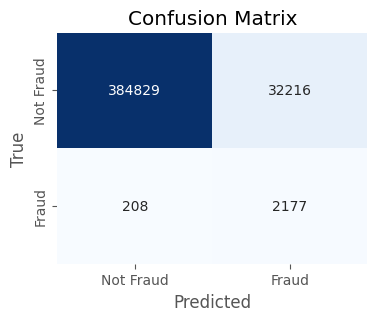

In [ ]:
# Generate confusion matrix
conf_matrix_tree_b = confusion_matrix(test_y, pred_y_dt_b)

# Visualize the confusion matrix using seaborn
plt.figure(figsize=(4,3))
sns.heatmap(conf_matrix_tree_b, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.under_sampling import RandomUnderSampler

# Apply undersampling to the training set
undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
train_X_resampled, train_y_resampled = undersampler.fit_resample(train_X, train_y)

# Create a Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model on the resampled data
dt_classifier.fit(train_X_resampled, train_y_resampled)

# Get feature importances
feature_importance = dt_classifier.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print feature importances
print("Feature Importance:")
print(feature_importance_df)

# Make predictions on the testing set
pred_y_dt_b = dt_classifier.predict(test_X)

# Evaluate the model
accuracy_dt = accuracy_score(test_y, pred_y_dt_b)
print(f"\nAccuracy: {accuracy_dt}")
print("\nDecision Tree Classifier:")
print(classification_report(test_y, pred_y_dt_b))

Feature Importance:
                      Feature  Importance
0                         amt    0.741018
2                  trans_hour    0.120983
3                         age    0.037410
1                    city_pop    0.035484
5                         lat    0.023590
6                        long    0.022747
7           trans_day_of_week    0.008232
10   age_category_Middle-aged    0.003981
4                    gender_M    0.003305
9         age_category_Adults    0.001518
8   age_category_Young Adults    0.000718
11       age_category_Seniors    0.000644
12       age_category_Retired    0.000368

Accuracy: 0.9226950861883986

Decision Tree Classifier:
              precision    recall  f1-score   support

       False       1.00      0.92      0.96    417045
        True       0.06      0.91      0.12      2385

    accuracy                           0.92    419430
   macro avg       0.53      0.92      0.54    419430
weighted avg       0.99      0.92      0.95    419430



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the resampled data
rf_classifier.fit(train_X_resampled, train_y_resampled)

# Predict on the test data
rf_predictions = rf_classifier.predict(test_X)

# Evaluation
print("Random Forest Classifier Evaluation:")
print("Accuracy:", accuracy_score(test_y, rf_predictions))
print("Confusion Matrix:\n", confusion_matrix(test_y, rf_predictions))
print("Classification Report:\n", classification_report(test_y, rf_predictions))


Random Forest Classifier Evaluation:
Accuracy: 0.9434256014114394
Confusion Matrix:
 [[393487  23558]
 [   171   2214]]
Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.94      0.97    417045
        True       0.09      0.93      0.16      2385

    accuracy                           0.94    419430
   macro avg       0.54      0.94      0.56    419430
weighted avg       0.99      0.94      0.97    419430



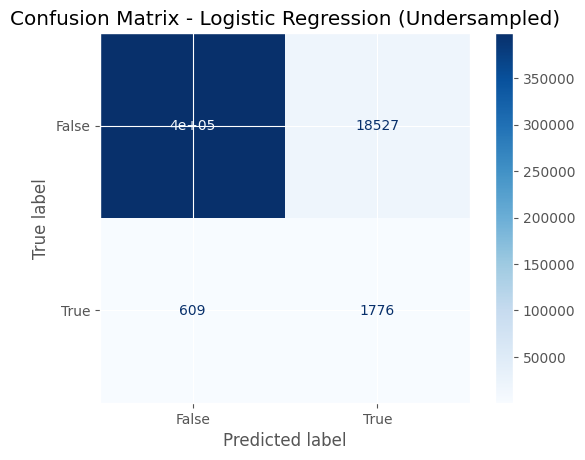

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(test_y, pred_y_logreg_b)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression (Undersampled)")
plt.show()


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Create a Naive Bayes classifier
nb_classifier = GaussianNB()

# Train the model on the resampled data
nb_classifier.fit(train_X_resampled, train_y_resampled)

# Predict on the test data
nb_predictions = nb_classifier.predict(test_X)

# Evaluation
print("Naive Bayes Classifier Evaluation:")
print("Accuracy:", accuracy_score(test_y, nb_predictions))
print("Confusion Matrix:\n", confusion_matrix(test_y, nb_predictions))
print("Classification Report:\n", classification_report(test_y, nb_predictions))


Naive Bayes Classifier Evaluation:
Accuracy: 0.9814867796771809
Confusion Matrix:
 [[410359   6686]
 [  1079   1306]]
Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.98      0.99    417045
        True       0.16      0.55      0.25      2385

    accuracy                           0.98    419430
   macro avg       0.58      0.77      0.62    419430
weighted avg       0.99      0.98      0.99    419430



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm_nb = confusion_matrix(test_y, nb_predictions)

# Display the confusion matrix
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_classifier.classes_)
disp_nb.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Naive Bayes Classifier (Undersampled)")
plt.show()


In [ ]:
pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=fbc739eb2e25d489ecdabdb795aab91838cc14489a662feb5d7b4f46dae04302
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
pip install eli5


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 2.7 MB/s eta 0:00:00


In [ ]:
# Import interpretability libraries
import lime
import lime.lime_tabular
import shap
import eli5
from eli5.sklearn import PermutationImportance


XGBoost Interpretability
--------------------------------------------------


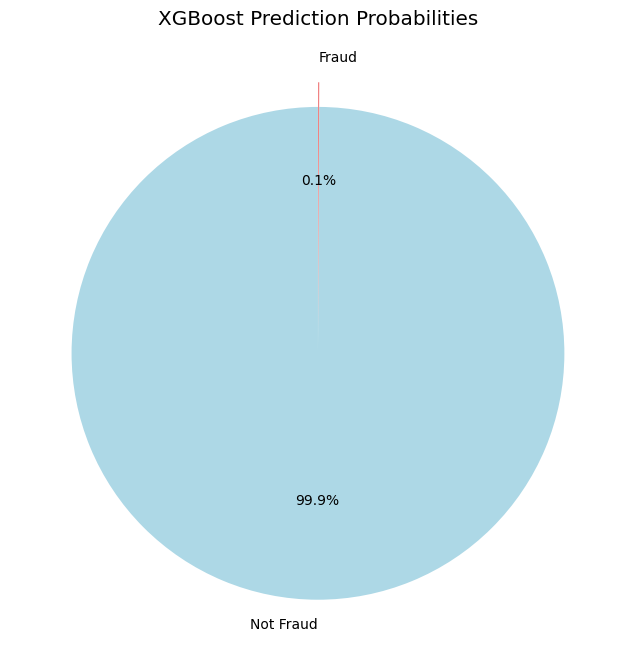


1. LIME Explanation


<Figure size 1000x600 with 0 Axes>

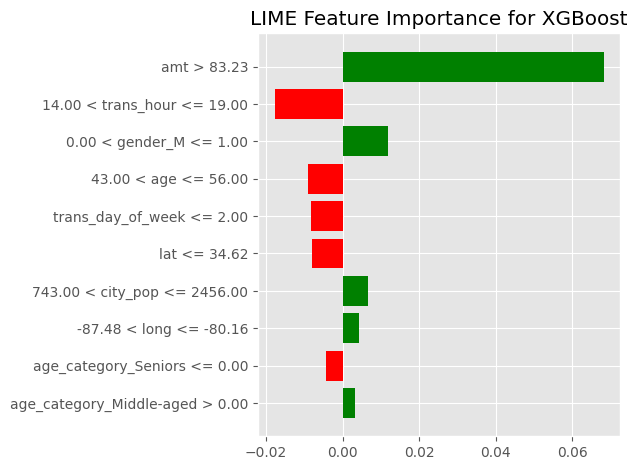


2. SHAP Explanation


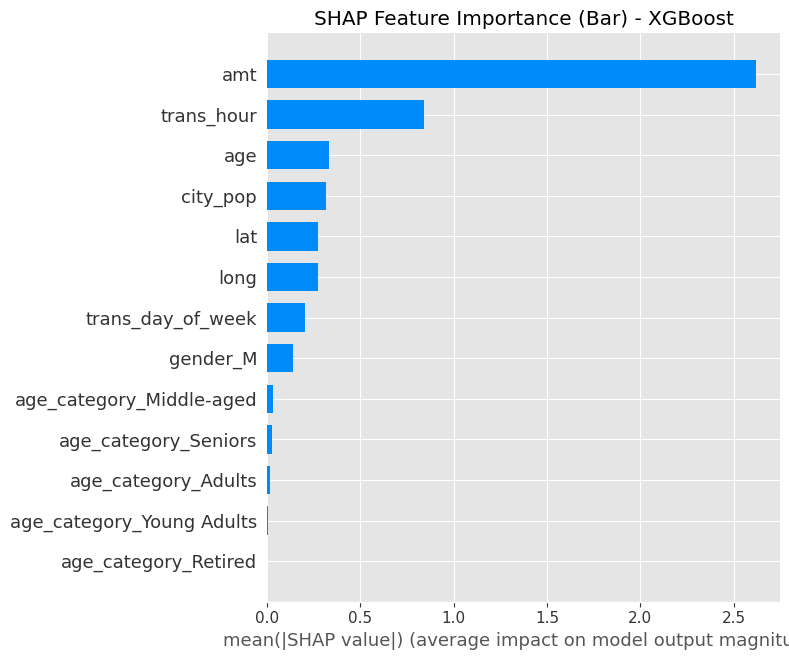

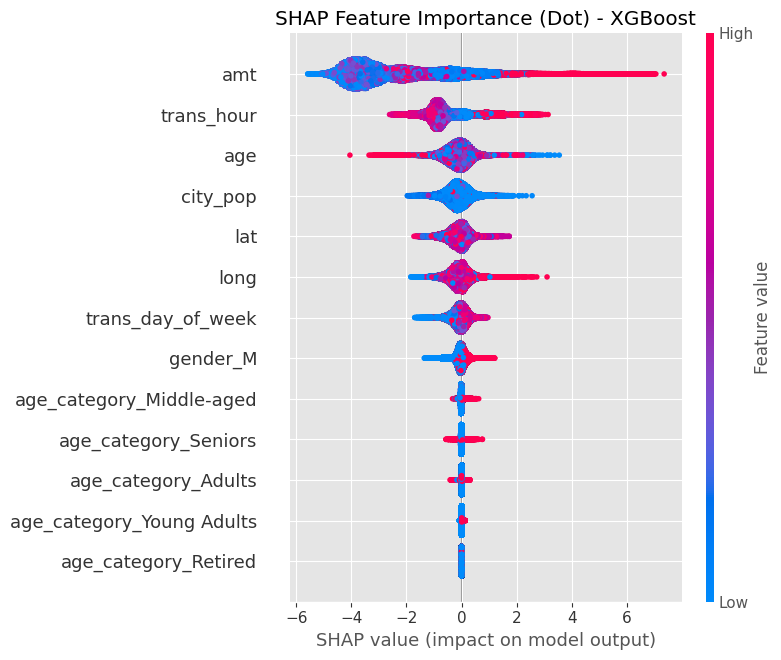

<Figure size 1200x400 with 0 Axes>

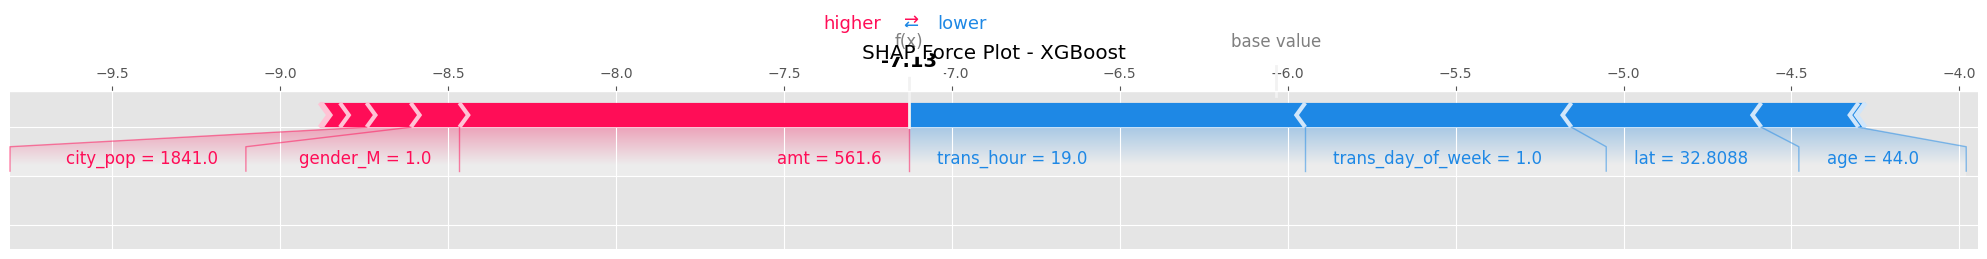


3. ELI5 Explanation


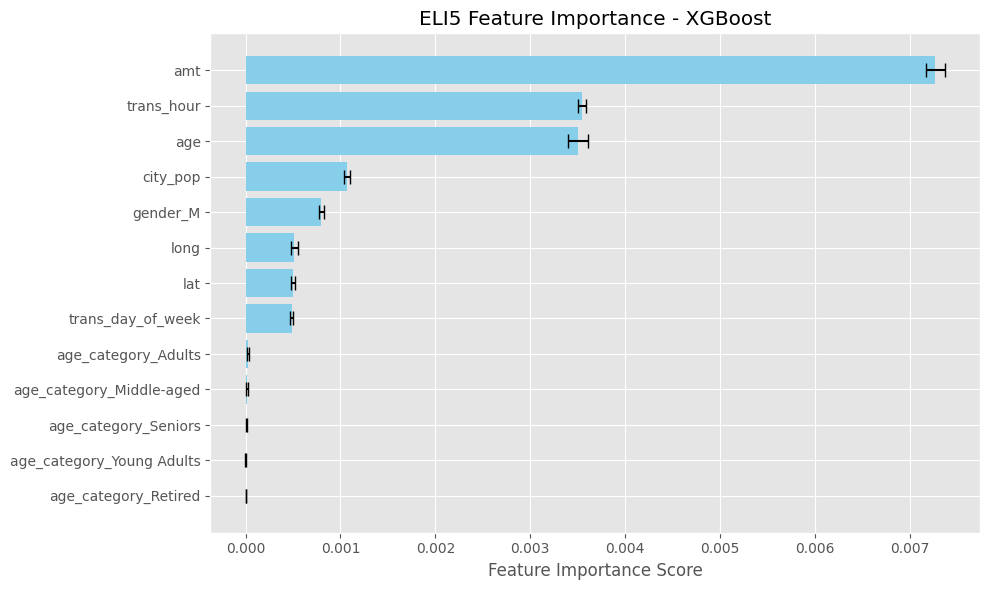


ELI5 Feature Importance Details:
Explained as: feature importances

Feature importances, computed as a decrease in score when feature
values are permuted (i.e. become noise). This is also known as 
permutation importance.

If feature importances are computed on the same data as used for training, 
they don't reflect importance of features for generalization. Use a held-out
dataset if you want generalization feature importances.

0.0073 ± 0.0002  amt
0.0035 ± 0.0001  trans_hour
0.0035 ± 0.0002  age
0.0011 ± 0.0001  city_pop
0.0008 ± 0.0001  gender_M
0.0005 ± 0.0001  long
0.0005 ± 0.0000  lat
0.0005 ± 0.0000  trans_day_of_week
0.0000 ± 0.0000  age_category_Adults
0.0000 ± 0.0000  age_category_Middle-aged
0.0000 ± 0.0000  age_category_Seniors
0.0000 ± 0.0000  age_category_Young Adults
     0 ± 0.0000  age_category_Retired

Logistic Regression Interpretability
--------------------------------------------------


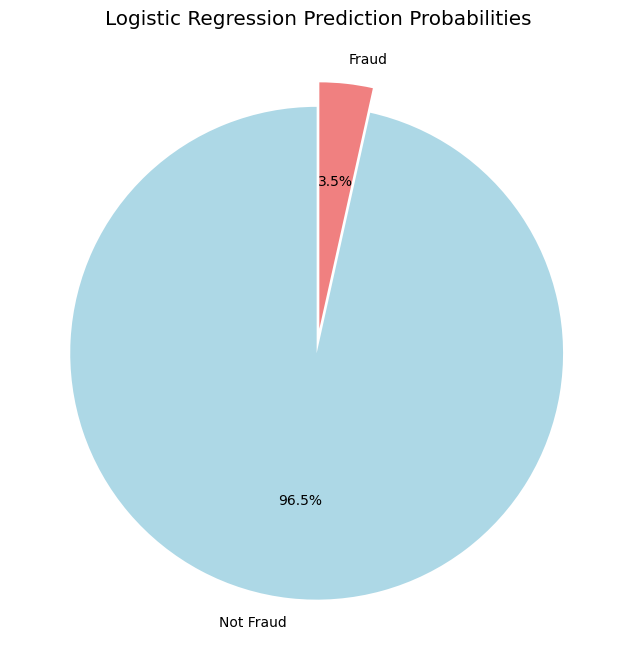


1. LIME Explanation


<Figure size 1000x600 with 0 Axes>

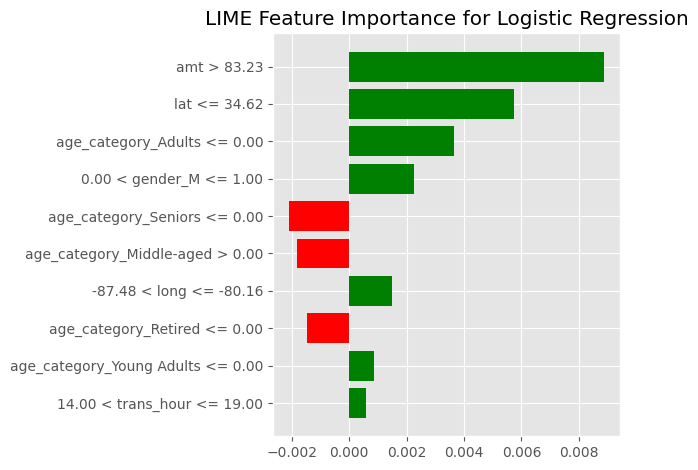


2. SHAP Explanation


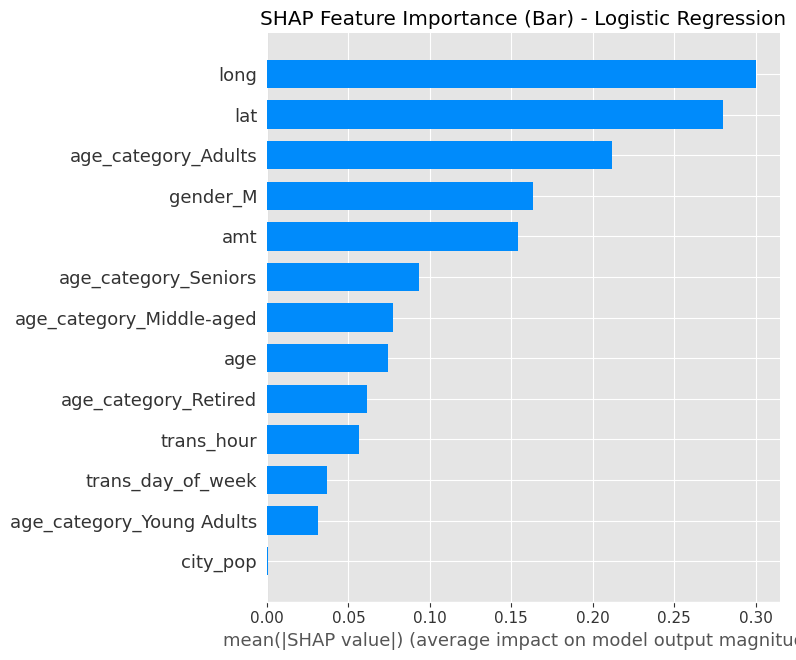

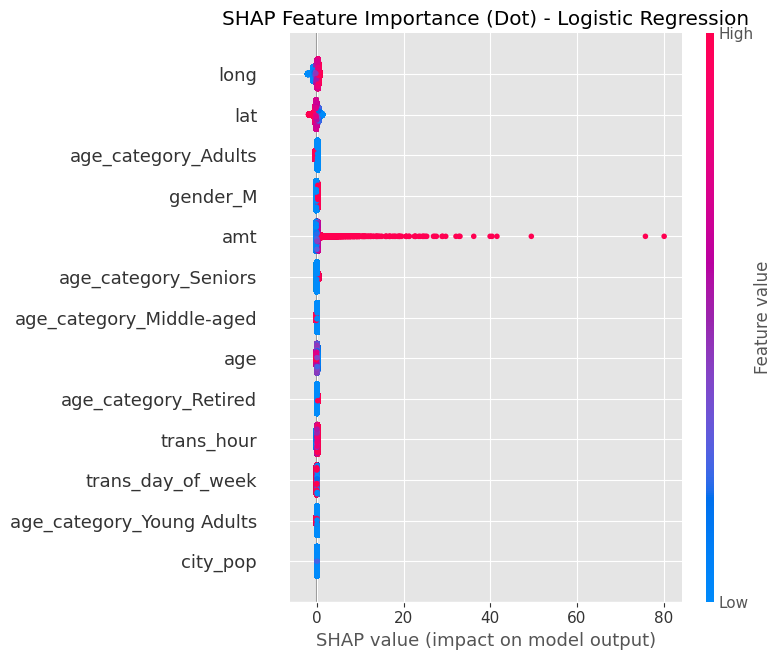

<Figure size 1200x400 with 0 Axes>

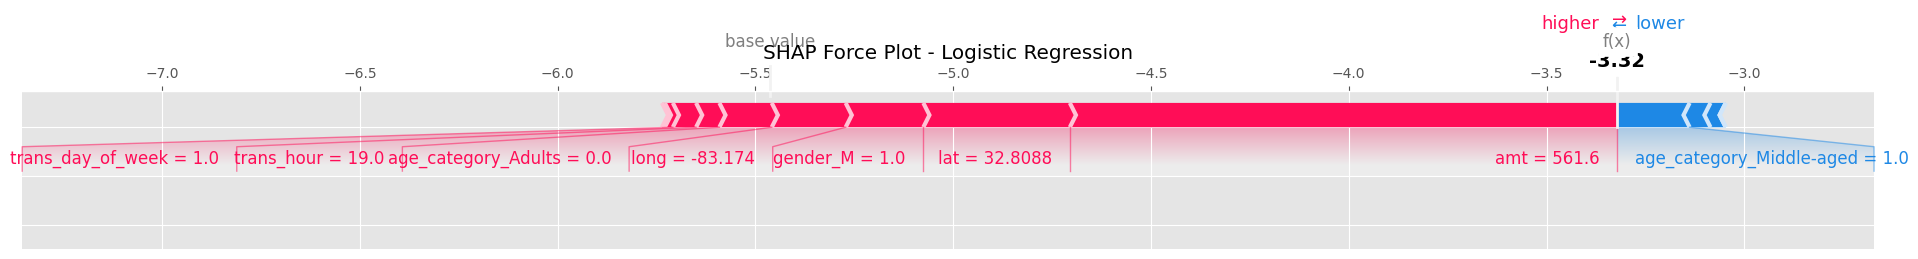


3. ELI5 Explanation


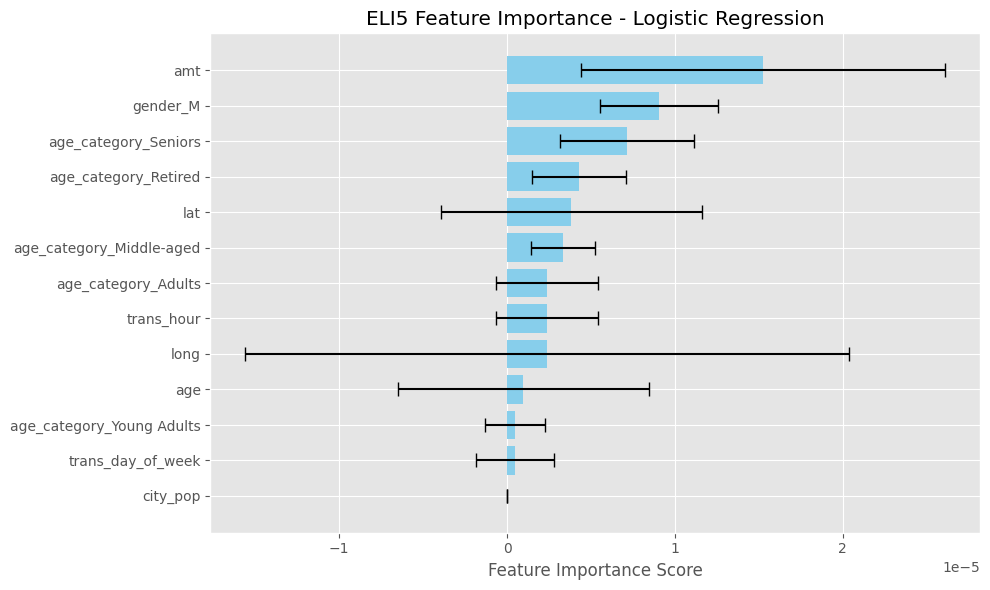


ELI5 Feature Importance Details:
Explained as: feature importances

Feature importances, computed as a decrease in score when feature
values are permuted (i.e. become noise). This is also known as 
permutation importance.

If feature importances are computed on the same data as used for training, 
they don't reflect importance of features for generalization. Use a held-out
dataset if you want generalization feature importances.

0.0000 ± 0.0000  gender_M
0.0000 ± 0.0000  age_category_Seniors
0.0000 ± 0.0000  age_category_Retired
0.0000 ± 0.0000  age_category_Middle-aged
0.0000 ± 0.0000  age_category_Adults
0.0000 ± 0.0000  long
0.0000 ± 0.0000  age
0.0000 ± 0.0000  age_category_Young Adults
0.0000 ± 0.0000  trans_day_of_week
     0 ± 0.0000  city_pop
-0.0000 ± 0.0000  trans_hour
-0.0000 ± 0.0000  lat
-0.0000 ± 0.0000  amt

Decision Tree Interpretability
--------------------------------------------------


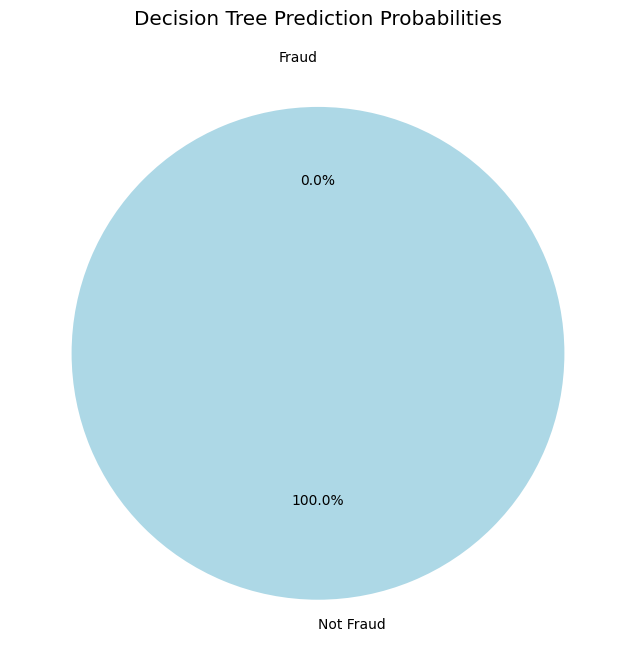


1. LIME Explanation


<Figure size 1000x600 with 0 Axes>

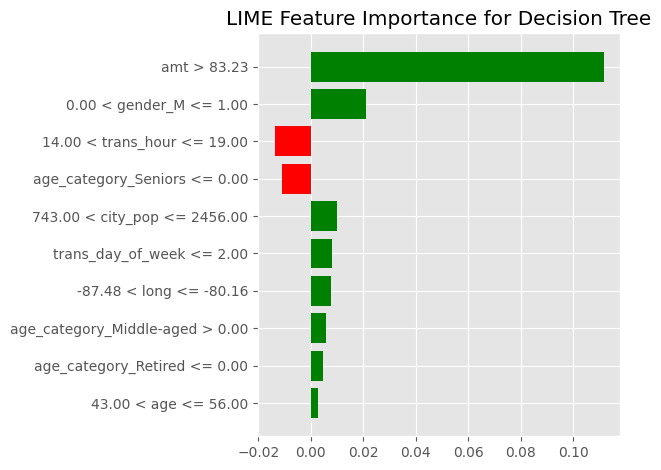


2. SHAP Explanation


<Figure size 1000x600 with 0 Axes>

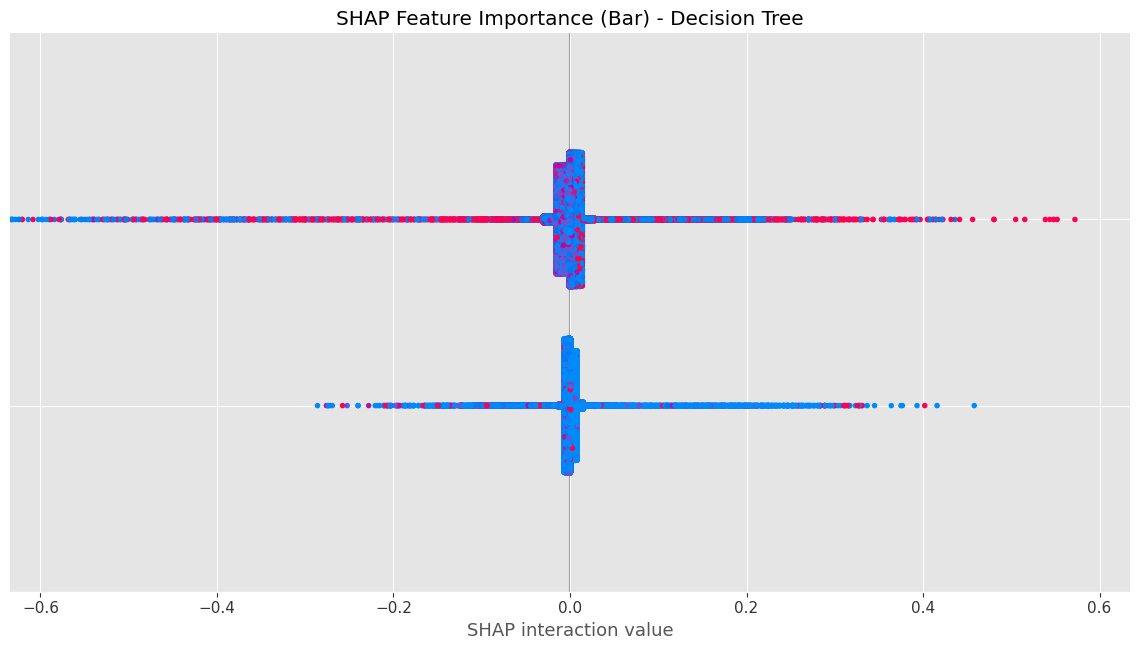

<Figure size 1000x600 with 0 Axes>

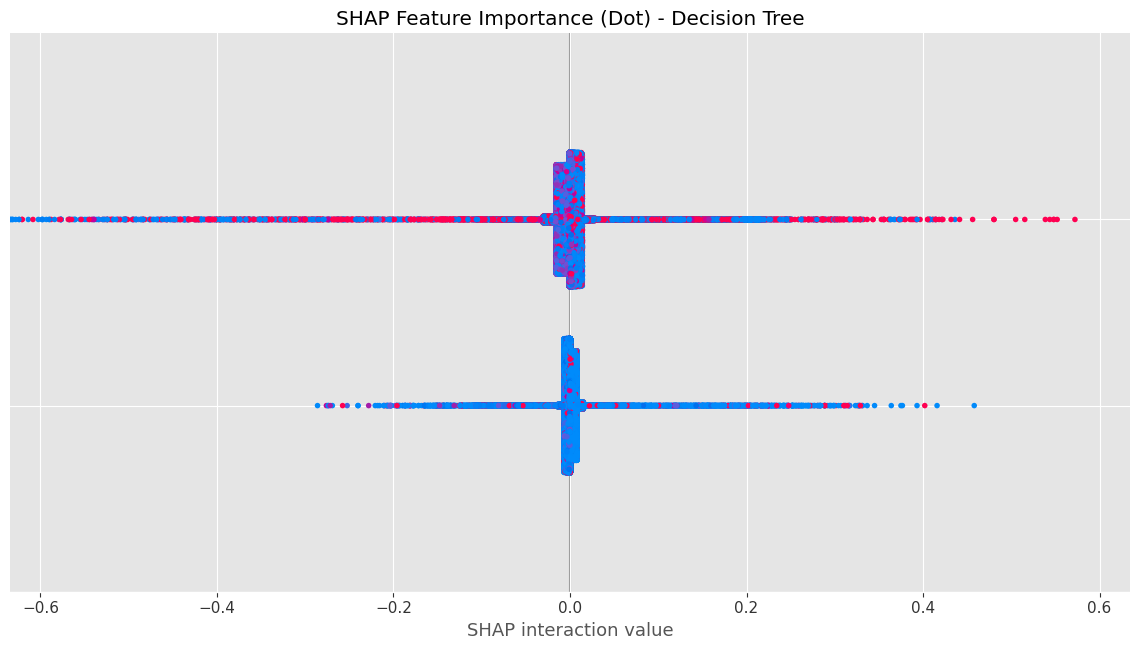

Could not generate SHAP force plot: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

3. ELI5 Explanation


<Figure size 1200x400 with 0 Axes>

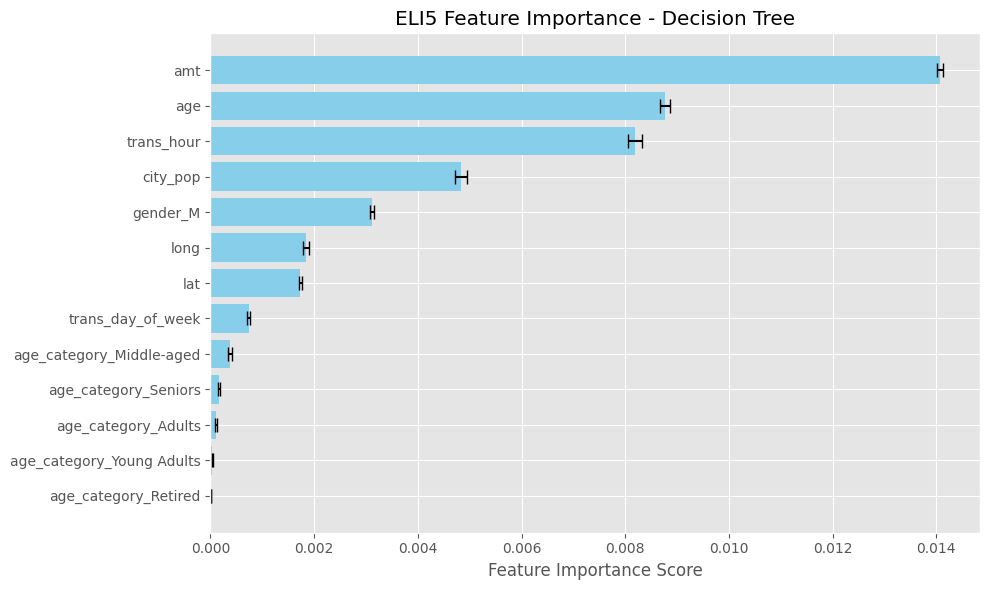


ELI5 Feature Importance Details:
Explained as: feature importances

Feature importances, computed as a decrease in score when feature
values are permuted (i.e. become noise). This is also known as 
permutation importance.

If feature importances are computed on the same data as used for training, 
they don't reflect importance of features for generalization. Use a held-out
dataset if you want generalization feature importances.

0.0141 ± 0.0001  amt
0.0088 ± 0.0002  age
0.0082 ± 0.0003  trans_hour
0.0048 ± 0.0002  city_pop
0.0031 ± 0.0001  gender_M
0.0018 ± 0.0001  long
0.0017 ± 0.0001  lat
0.0007 ± 0.0001  trans_day_of_week
0.0004 ± 0.0001  age_category_Middle-aged
0.0002 ± 0.0000  age_category_Seniors
0.0001 ± 0.0000  age_category_Adults
0.0000 ± 0.0000  age_category_Young Adults
0.0000 ± 0.0000  age_category_Retired

Random Forest Interpretability
--------------------------------------------------


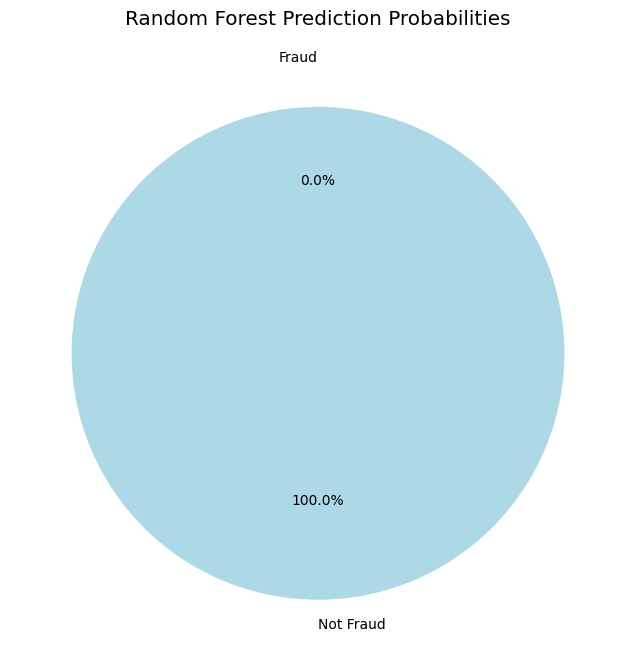


1. LIME Explanation


<Figure size 1000x600 with 0 Axes>

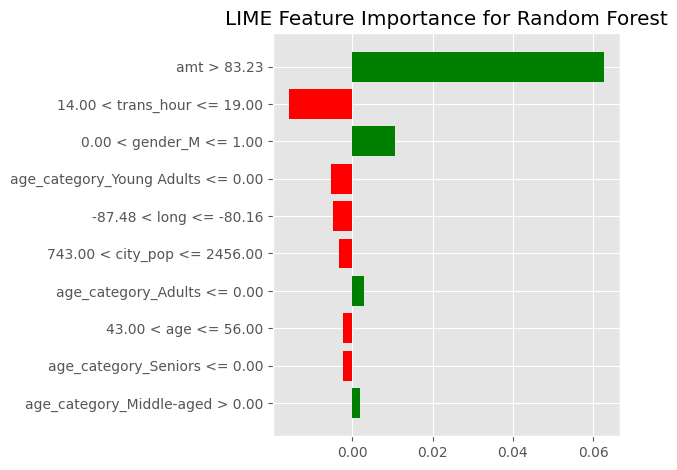

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lime
import lime.lime_tabular
import shap
import eli5
from eli5.sklearn import PermutationImportance
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

def interpret_model(model, model_name, train_X, valid_X, valid_y, predict_fn=None):
    # Convert data types first
    numeric_columns = ['amt', 'city_pop', 'trans_hour', 'age', 'lat', 'long', 'trans_day_of_week']
    boolean_columns = ['gender_M', 'age_category_Young Adults', 'age_category_Adults',
                      'age_category_Middle-aged', 'age_category_Seniors', 'age_category_Retired']

    train_X = train_X.copy()
    valid_X = valid_X.copy()

    for col in numeric_columns:
        train_X[col] = pd.to_numeric(train_X[col])
        valid_X[col] = pd.to_numeric(valid_X[col])

    for col in boolean_columns:
        train_X[col] = train_X[col].astype(int)
        valid_X[col] = valid_X[col].astype(int)

    print(f"\n{model_name} Interpretability")
    print("-" * 50)

    # Get prediction probabilities for the example instance
    i = 0
    if predict_fn:
        pred_proba = predict_fn(valid_X.iloc[i].to_frame().T)
    else:
        pred_proba = model.predict_proba(valid_X.iloc[i].to_frame().T)

    # PIE PLOT
    plt.figure(figsize=(8, 8))
    plt.pie(pred_proba[0], labels=['Not Fraud', 'Fraud'],
            autopct='%1.1f%%', startangle=90,
            colors=['lightblue', 'lightcoral'],
            explode=(0.05, 0.05))
    plt.title(f'{model_name} Prediction Probabilities')
    plt.show()

    # LIME
    print("\n1. LIME Explanation")
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=np.array(train_X),
        feature_names=train_X.columns,
        class_names=['Not Fraud', 'Fraud'],
        mode='classification'
    )

    exp = lime_explainer.explain_instance(
        data_row=valid_X.iloc[i],
        predict_fn=predict_fn if predict_fn else model.predict_proba
    )

    plt.figure(figsize=(10, 6))
    exp.as_pyplot_figure()
    plt.title(f'LIME Feature Importance for {model_name}')
    plt.tight_layout()
    plt.show()

    # SHAP
    print("\n2. SHAP Explanation")
    if isinstance(model, LogisticRegression):
        explainer = shap.LinearExplainer(model, train_X)
    else:
        explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(valid_X)

    # Summary Plot (Bar)
    plt.figure(figsize=(10, 6))
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], valid_X, plot_type='bar', show=False)
    else:
        shap.summary_plot(shap_values, valid_X, plot_type='bar', show=False)
    plt.title(f'SHAP Feature Importance (Bar) - {model_name}')
    plt.tight_layout()
    plt.show()

    # Summary Plot (Dot)
    plt.figure(figsize=(10, 6))
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], valid_X, show=False)
    else:
        shap.summary_plot(shap_values, valid_X, show=False)
    plt.title(f'SHAP Feature Importance (Dot) - {model_name}')
    plt.tight_layout()
    plt.show()

    # SHAP Force Plot
    try:
        plt.figure(figsize=(12, 4))
        if isinstance(shap_values, list):
            expected_value = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
            shap.force_plot(
                expected_value,
                shap_values[1][0],
                valid_X.iloc[0],
                matplotlib=True,
                show=False
            )
        else:
            shap.force_plot(
                explainer.expected_value,
                shap_values[0],
                valid_X.iloc[0],
                matplotlib=True,
                show=False
            )
        plt.title(f'SHAP Force Plot - {model_name}')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not generate SHAP force plot: {str(e)}")

    # ELI5
    print("\n3. ELI5 Explanation")
    perm = PermutationImportance(model, random_state=42).fit(valid_X, valid_y)

    weights_df = pd.DataFrame({
        'Feature': valid_X.columns,
        'Importance': np.abs(perm.feature_importances_),
        'Std': perm.feature_importances_std_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(weights_df)), weights_df['Importance'],
            xerr=weights_df['Std'],
            align='center',
            color='skyblue',
            ecolor='black',
            capsize=5)
    plt.yticks(range(len(weights_df)), weights_df['Feature'])
    plt.xlabel('Feature Importance Score')
    plt.title(f'ELI5 Feature Importance - {model_name}')
    plt.tight_layout()
    plt.show()

    print('\nELI5 Feature Importance Details:')
    print(eli5.format_as_text(eli5.explain_weights(perm, feature_names=list(valid_X.columns))))

# --- MODEL TRAINING (Assuming train_X, train_y, valid_X, valid_y already prepared) ---

# Logistic Regression
logreg_classifier = LogisticRegression(max_iter=1000, random_state=42)
logreg_classifier.fit(train_X, train_y)

# Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(train_X, train_y)

# Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(train_X, train_y)

# Naive Bayes
nb_classifier = GaussianNB()
nb_classifier.fit(train_X, train_y)

# XGBoost
xgb_classifier = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_classifier.fit(train_X, train_y)

# --- INTERPRETATION ---

interpret_model(xgb_classifier, "XGBoost", train_X, valid_X, valid_y)
interpret_model(logreg_classifier, "Logistic Regression", train_X, valid_X, valid_y)
interpret_model(dt_classifier, "Decision Tree", train_X, valid_X, valid_y)
interpret_model(rf_classifier, "Random Forest", train_X, valid_X, valid_y)
interpret_model(nb_classifier, "Naive Bayes", train_X, valid_X, valid_y)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lime.lime_tabular
import shap
import eli5
from eli5.sklearn import PermutationImportance
from sklearn.naive_bayes import GaussianNB

# Naive Bayes Classifier Training
nb_classifier = GaussianNB()
nb_classifier.fit(train_X, train_y)

# Interpretability Function for Naive Bayes
def interpret_naive_bayes(model, train_X, valid_X, valid_y):
    numeric_columns = ['amt', 'city_pop', 'trans_hour', 'age', 'lat', 'long', 'trans_day_of_week']
    boolean_columns = ['gender_M', 'age_category_Young Adults', 'age_category_Adults',
                       'age_category_Middle-aged', 'age_category_Seniors', 'age_category_Retired']

    # Ensure correct data types
    for col in numeric_columns:
        train_X[col] = pd.to_numeric(train_X[col])
        valid_X[col] = pd.to_numeric(valid_X[col])
    for col in boolean_columns:
        train_X[col] = train_X[col].astype(int)
        valid_X[col] = valid_X[col].astype(int)

    print("\nNaive Bayes Interpretability")
    print("-" * 50)

    i = 0
    pred_proba = model.predict_proba(valid_X.iloc[i].to_frame().T)

    # PIE CHART
    plt.figure(figsize=(8, 8))
    plt.pie(pred_proba[0], labels=['Not Fraud', 'Fraud'],
            autopct='%1.1f%%', startangle=90,
            colors=['lightblue', 'lightcoral'],
            explode=(0.05, 0.05))
    plt.title('Naive Bayes Prediction Probabilities')
    plt.show()

    # LIME
    print("\n1. LIME Explanation")
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=np.array(train_X),
        feature_names=train_X.columns,
        class_names=['Not Fraud', 'Fraud'],
        mode='classification'
    )

    exp = lime_explainer.explain_instance(
        data_row=valid_X.iloc[i],
        predict_fn=model.predict_proba
    )

    exp.as_pyplot_figure()
    plt.title('LIME Feature Importance - Naive Bayes')
    plt.tight_layout()
    plt.show()

    # SHAP
    print("\n2. SHAP Explanation")
    try:
        explainer = shap.KernelExplainer(model.predict_proba, train_X.sample(100))
        shap_values = explainer.shap_values(valid_X.iloc[[i]])

        shap.summary_plot(shap_values[1], valid_X.iloc[[i]], plot_type="bar", show=False)
        plt.title('SHAP Feature Importance (Bar) - Naive Bayes')
        plt.tight_layout()
        plt.show()

        shap.summary_plot(shap_values[1], valid_X.iloc[[i]], show=False)
        plt.title('SHAP Feature Importance (Dot) - Naive Bayes')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"SHAP failed: {str(e)}")

    # ELI5
    print("\n3. ELI5 Explanation")
    perm = PermutationImportance(model, random_state=42).fit(valid_X, valid_y)
    weights_df = pd.DataFrame({
        'Feature': valid_X.columns,
        'Importance': np.abs(perm.feature_importances_),
        'Std': perm.feature_importances_std_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(weights_df['Feature'], weights_df['Importance'], xerr=weights_df['Std'],
             color='skyblue', ecolor='black', capsize=5)
    plt.xlabel('Feature Importance Score')
    plt.title('ELI5 Feature Importance - Naive Bayes')
    plt.tight_layout()
    plt.show()

    print('\nELI5 Feature Importance Details:')
    print(eli5.format_as_text(eli5.explain_weights(perm, feature_names=list(valid_X.columns))))

# Example usage
interpret_naive_bayes(nb_classifier, train_X.copy(), valid_X.copy(), valid_y)
